In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
import seaborn as sns
import sklearn as sk
import datetime
import matplotlib.pyplot as plt

In [4]:
credits = pd.read_csv(r"C:\Users\Acer\OneDrive\Desktop\Recommendation System\credits.csv")
keywords = pd.read_csv(r"C:\Users\Acer\OneDrive\Desktop\Recommendation System\keywords.csv")
links = pd.read_csv(r"C:\Users\Acer\OneDrive\Desktop\Recommendation System\links.csv")
links_small = pd.read_csv(r"C:\Users\Acer\OneDrive\Desktop\Recommendation System\links_small.csv")
movies_metadata = pd.read_csv(r"C:\Users\Acer\OneDrive\Desktop\Recommendation System\movies_metadata.csv")
ratings = pd.read_csv(r"C:\Users\Acer\OneDrive\Desktop\Recommendation System\ratings.csv")
ratings_small = pd.read_csv(r"C:\Users\Acer\OneDrive\Desktop\Recommendation System\ratings_small.csv")

C:\Users\Acer\AppData\Local\Temp\ipykernel_13872\2977538195.py:5: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  movies_metadata = pd.read_csv(r"C:\Users\Acer\OneDrive\Desktop\Recommendation System\movies_metadata.csv")


In [5]:
credits.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45476 entries, 0 to 45475
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   cast    45476 non-null  object
 1   crew    45476 non-null  object
 2   id      45476 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.0+ MB


In [6]:
keywords.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46419 entries, 0 to 46418
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        46419 non-null  int64 
 1   keywords  46419 non-null  object
dtypes: int64(1), object(1)
memory usage: 725.4+ KB


In [7]:
links.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45843 entries, 0 to 45842
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movieId  45843 non-null  int64  
 1   imdbId   45843 non-null  int64  
 2   tmdbId   45624 non-null  float64
dtypes: float64(1), int64(2)
memory usage: 1.0 MB


In [8]:
links_small.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9125 entries, 0 to 9124
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movieId  9125 non-null   int64  
 1   imdbId   9125 non-null   int64  
 2   tmdbId   9112 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 214.0 KB


In [16]:
movies = pd.read_csv(r"C:\Users\Acer\OneDrive\Desktop\Recommendation System\movies_metadata.csv", low_memory=False)

# a few rows have dates in the id column
movies["id"] = pd.to_numeric(movies["id"], errors="coerce")
movies = movies.dropna(subset=["id", "title"]).copy()
movies["id"] = movies["id"].astype(int)
movies = movies.drop_duplicates("id")

credits["id"] = credits["id"].astype(int)
keywords["id"] = keywords["id"].astype(int)

movies = movies.merge(credits, on="id").merge(keywords, on="id")

In [18]:
import ast

# keep only the movies in links_small (~9k). The full 45k x 45k similarity
# matrix would need roughly 16 GB of RAM, this one needs well under 1 GB.
small_ids = links_small["tmdbId"].dropna().astype(int)
movies = movies[movies["id"].isin(small_ids)].reset_index(drop=True)

def parse_names(text, limit=None):
    """Turn a stringified list of dicts into a list of names."""
    try:
        items = ast.literal_eval(text)
    except (ValueError, SyntaxError, TypeError):
        return []
    names = [d["name"] for d in items]
    return names[:limit] if limit else names

def get_director(text):
    try:
        for d in ast.literal_eval(text):
            if d["job"] == "Director":
                return d["name"]
    except (ValueError, SyntaxError, TypeError):
        pass
    return ""

def squash(names):
    # "Tom Hanks" -> "tomhanks", so two different Toms don't match each other
    return [n.replace(" ", "").lower() for n in names]

genres   = movies["genres"].apply(lambda x: squash(parse_names(x)))
kw       = movies["keywords"].apply(lambda x: squash(parse_names(x)))
cast     = movies["cast"].apply(lambda x: squash(parse_names(x, limit=3)))
director = movies["crew"].apply(lambda x: squash([get_director(x)]))

overview = movies["overview"].fillna("").str.lower()

# director repeated so it carries a bit more weight
movies["soup"] = (
    overview + " "
    + genres.str.join(" ") + " "
    + kw.str.join(" ") + " "
    + cast.str.join(" ") + " "
    + director.str.join(" ") + " " + director.str.join(" ")
)

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

tfidf = TfidfVectorizer(stop_words="english")
mat = tfidf.fit_transform(movies["soup"])
sim = linear_kernel(mat, mat)

idx = pd.Series(movies.index, index=movies["title"]).drop_duplicates()

def recommend(title, n=10):
    i = idx[title]
    scores = sorted(enumerate(sim[i]), key=lambda x: x[1], reverse=True)[1:n+1]
    return movies["title"].iloc[[s[0] for s in scores]]

In [21]:
movies["vote_count"] = pd.to_numeric(movies["vote_count"], errors="coerce").fillna(0)
movies["vote_average"] = pd.to_numeric(movies["vote_average"], errors="coerce").fillna(0)

C = movies["vote_average"].mean()
m = movies["vote_count"].quantile(0.60)

v, R = movies["vote_count"], movies["vote_average"]
movies["wr"] = (v / (v + m)) * R + (m / (v + m)) * C

def recommend_v2(title, n=10, pool=30):
    if title not in idx:
        return f"'{title}' not found"
    i = idx[title]
    top = sorted(enumerate(sim[i]), key=lambda x: x[1], reverse=True)[1:pool+1]
    cand = movies.iloc[[t[0] for t in top]]
    cand = cand[cand["vote_count"] >= m]
    return cand.sort_values("wr", ascending=False)["title"].head(n)

recommend_v2("The Dark Knight")

7592                                  Inception
8549                               Interstellar
3369                                    Memento
6575                               The Prestige
7971                      The Dark Knight Rises
8270    Batman: The Dark Knight Returns, Part 2
6174                              Batman Begins
8531                             The Lego Movie
8205    Batman: The Dark Knight Returns, Part 1
7603                 Batman: Under the Red Hood
Name: title, dtype: object

In [22]:
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers

# link ratings (movieId) to your movies (tmdbId)
r = ratings_small.merge(links_small[["movieId", "tmdbId"]], on="movieId").dropna(subset=["tmdbId"])
r["tmdbId"] = r["tmdbId"].astype(int)
r = r[r["tmdbId"].isin(movies["id"])].copy()

# encode ids as 0..N-1
user2idx  = {u: i for i, u in enumerate(r["userId"].unique())}
movie2idx = {mv: i for i, mv in enumerate(r["tmdbId"].unique())}
r["u"] = r["userId"].map(user2idx)
r["m"] = r["tmdbId"].map(movie2idx)

mu = r["rating"].mean()
train, test = train_test_split(r, test_size=0.2, random_state=42)

n_users, n_movies, dim = len(user2idx), len(movie2idx), 32

u_in = keras.Input(shape=(1,))
m_in = keras.Input(shape=(1,))
u_vec = layers.Flatten()(layers.Embedding(n_users, dim, embeddings_regularizer=keras.regularizers.l2(1e-5))(u_in))
m_vec = layers.Flatten()(layers.Embedding(n_movies, dim, embeddings_regularizer=keras.regularizers.l2(1e-5))(m_in))
u_b   = layers.Flatten()(layers.Embedding(n_users, 1)(u_in))
m_b   = layers.Flatten()(layers.Embedding(n_movies, 1)(m_in))
out = layers.Add()([layers.Dot(axes=1)([u_vec, m_vec]), u_b, m_b])

model = keras.Model([u_in, m_in], out)
model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse",
              metrics=[keras.metrics.RootMeanSquaredError()])

model.fit(
    [train["u"], train["m"]], train["rating"] - mu,
    validation_data=([test["u"], test["m"]], test["rating"] - mu),
    epochs=30, batch_size=256,
    callbacks=[keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)],
)

Epoch 1/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.0972 - root_mean_squared_error: 1.0468 - val_loss: 0.9907 - val_root_mean_squared_error: 0.9948
Epoch 2/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.9728 - root_mean_squared_error: 0.9854 - val_loss: 0.8814 - val_root_mean_squared_error: 0.9366
Epoch 3/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.8041 - root_mean_squared_error: 0.8935 - val_loss: 0.8121 - val_root_mean_squared_error: 0.8954
Epoch 4/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6788 - root_mean_squared_error: 0.8165 - val_loss: 0.7922 - val_root_mean_squared_error: 0.8806
Epoch 5/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5828 - root_mean_squared_error: 0.7513 - val_loss: 0.7897 - val_root_mean_squared_error: 0.8758
Epoch 6/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4989 - root_mean_squared_error: 0.6890 - val_loss: 0.7946 - val_root_mean_squared_error: 0.8754
Epoch 7/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step 

In [23]:
def hybrid(user_id, title, n=10, pool=50):
    if title not in idx or user_id not in user2idx:
        return "unknown user or title"
    i = idx[title]
    top = sorted(enumerate(sim[i]), key=lambda x: x[1], reverse=True)[1:pool+1]
    cand = movies.iloc[[t[0] for t in top]]
    cand = cand[cand["id"].isin(movie2idx)]          # only movies with ratings

    u = np.full(len(cand), user2idx[user_id])
    mv = cand["id"].map(movie2idx).values
    cand = cand.assign(pred=model.predict([u, mv], verbose=0).ravel() + mu)
    return cand.sort_values("pred", ascending=False)[["title", "pred"]].head(n)

hybrid(user_id=1, title="The Dark Knight")

,title,pred
3621,Family Business,3.344624
48,The Usual Suspects,3.330904
8205,"Batman: The Dark Knight Returns, Part 1",3.330375
6597,Harsh Times,3.328696
1122,Batman Returns,3.325356
5537,To End All Wars,3.321951
8549,Interstellar,3.317972
7383,Law Abiding Citizen,3.314226
3551,Criminal Law,3.299027
8531,The Lego Movie,3.297466


In [27]:
from scipy import sparse

folder = r"C:\Users\Acer\OneDrive\Desktop\Recommendation System"
movies[["title", "vote_count", "wr"]].to_csv(folder + r"\movies_app.csv", index=False)
sparse.save_npz(folder + r"\mat.npz", mat)

RMSE: 0.876 (baseline 1.050)   MAE: 0.673
Accuracy      0.631
Precision     0.842
Recall        0.353
F1            0.497
ROC AUC       0.783
Precision@10  0.658
Recall@10     0.687


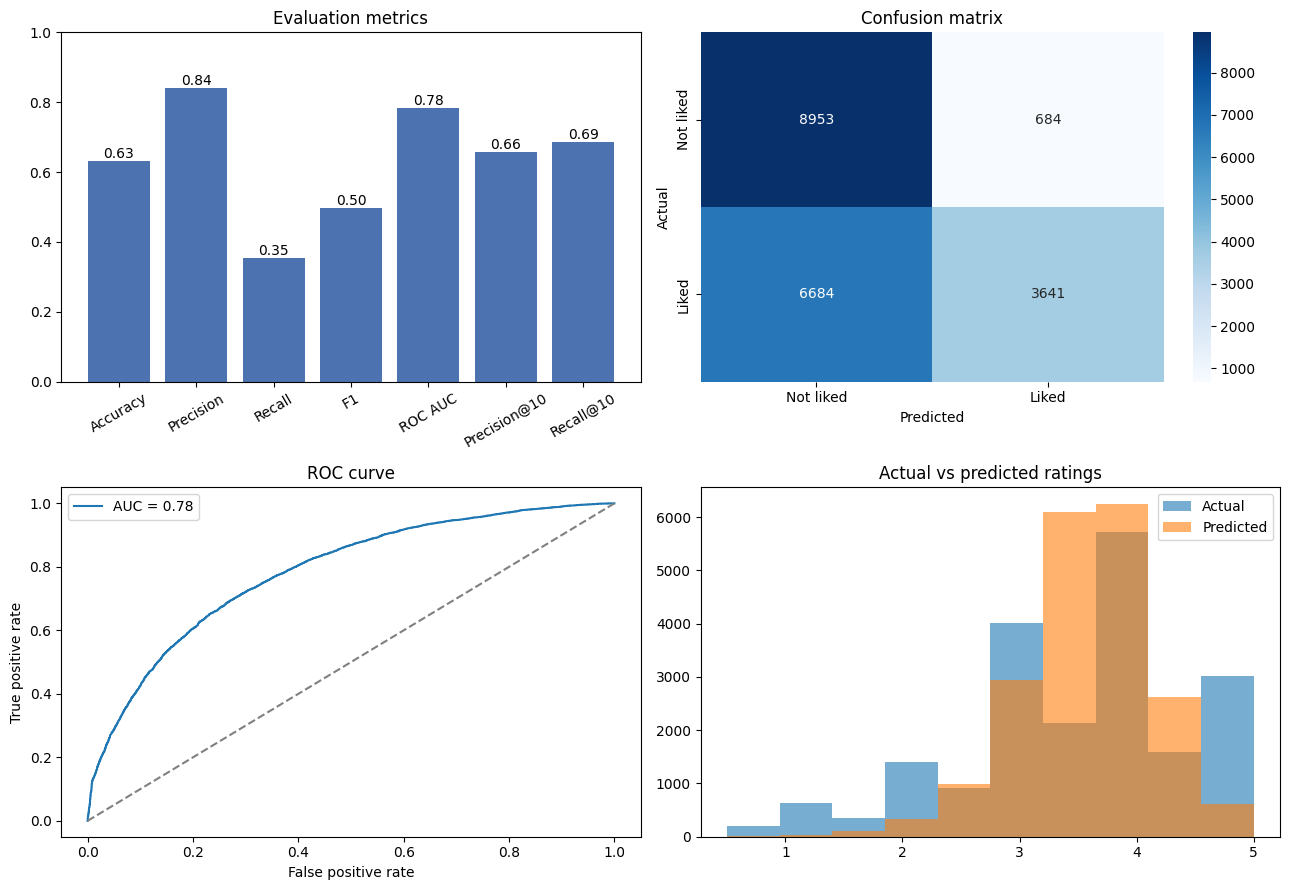

In [29]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, roc_auc_score,
                             mean_squared_error, mean_absolute_error)

# predictions on the held-out test set
pred = model.predict([test["u"].to_numpy(), test["m"].to_numpy()],
                     batch_size=1024, verbose=0).ravel() + mu
pred = np.clip(pred, 0.5, 5)
y = test["rating"].values

# regression metrics (vs. a baseline that always predicts the mean)
rmse = np.sqrt(mean_squared_error(y, pred))
mae  = mean_absolute_error(y, pred)
base_rmse = np.sqrt(mean_squared_error(y, np.full_like(y, train["rating"].mean())))

# classification metrics: liked = rating >= 4
y_true = (y >= 4).astype(int)
y_pred = (pred >= 4).astype(int)
scores = {
    "Accuracy":  accuracy_score(y_true, y_pred),
    "Precision": precision_score(y_true, y_pred),
    "Recall":    recall_score(y_true, y_pred),
    "F1":        f1_score(y_true, y_pred),
    "ROC AUC":   roc_auc_score(y_true, pred),
}

# ranking metrics: for each user, rank their test movies by predicted rating
t = test.assign(pred=pred, rel=y_true)
p_at_k, r_at_k = [], []
for _, g in t.groupby("userId"):
    top = g.sort_values("pred", ascending=False).head(10)
    p_at_k.append(top["rel"].mean())
    if g["rel"].sum() > 0:
        r_at_k.append(top["rel"].sum() / g["rel"].sum())
scores["Precision@10"] = np.mean(p_at_k)
scores["Recall@10"]    = np.mean(r_at_k)

print(f"RMSE: {rmse:.3f} (baseline {base_rmse:.3f})   MAE: {mae:.3f}")
for k, v in scores.items():
    print(f"{k:13s} {v:.3f}")

# ---- plots ----
fig, ax = plt.subplots(2, 2, figsize=(13, 9))

bars = ax[0, 0].bar(scores.keys(), scores.values(), color="#4C72B0")
ax[0, 0].set_ylim(0, 1); ax[0, 0].set_title("Evaluation metrics")
ax[0, 0].tick_params(axis="x", rotation=30)
ax[0, 0].bar_label(bars, fmt="%.2f")

sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt="d", cmap="Blues", ax=ax[0, 1],
            xticklabels=["Not liked", "Liked"], yticklabels=["Not liked", "Liked"])
ax[0, 1].set_title("Confusion matrix"); ax[0, 1].set_xlabel("Predicted"); ax[0, 1].set_ylabel("Actual")

fpr, tpr, _ = roc_curve(y_true, pred)
ax[1, 0].plot(fpr, tpr, label=f"AUC = {scores['ROC AUC']:.2f}")
ax[1, 0].plot([0, 1], [0, 1], "--", color="gray")
ax[1, 0].set_title("ROC curve"); ax[1, 0].set_xlabel("False positive rate")
ax[1, 0].set_ylabel("True positive rate"); ax[1, 0].legend()

ax[1, 1].hist(y, bins=10, alpha=0.6, label="Actual")
ax[1, 1].hist(pred, bins=10, alpha=0.6, label="Predicted")
ax[1, 1].set_title("Actual vs predicted ratings"); ax[1, 1].legend()

plt.tight_layout(); plt.show()

In [30]:
folder = r"C:\Users\Acer\OneDrive\Desktop\Recommendation System"
out = movies[["title", "vote_count", "vote_average", "wr", "overview", "poster_path"]].copy()
out["genres"] = movies["genres"].apply(lambda x: ", ".join(parse_names(x)))
out["year"] = pd.to_datetime(movies["release_date"], errors="coerce").dt.year
out["overview"] = out["overview"].fillna("")
out.to_csv(folder + r"\movies_app.csv", index=False)